In [110]:
import pandas as pd
import numpy as np
import seaborn as sns
import math
import difflib
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, mean_squared_error, silhouette_score
from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve, learning_curve, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## **Data Overview**

In [111]:
df = pd.read_csv("Bangladesh_Crime_Dataset_B.csv", sep = ",")
df.head()

,Unnamed: 0,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,...,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime
0,0,7,29,wednesday,0,morning,dhaka,dhaka,6.1,10,...,8.42,30551,74.6,4289,99,17,60,242,64,murder
1,1,1,2,wednesday,0,night,dhaka,dhaka,0.0,10,...,8.42,30551,74.6,4289,99,17,60,242,64,murder
2,2,1,4,tuesday,0,night,dhaka,dhaka,0.0,10,...,8.42,30551,74.6,4289,99,17,60,242,64,murder
3,3,3,9,friday,1,night,dhaka,dhaka,0.0,10,...,8.42,30551,74.6,4289,99,17,60,242,64,murder
4,4,8,34,thursday,0,night,dhaka,dhaka,21.9,9,...,8.42,30551,74.6,4289,99,17,60,242,64,murder


In [112]:
df.columns

Index(['Unnamed: 0', 'incident_month', 'incident_week', 'incident_weekday',
       'weekend', 'part_of_the_day', 'incident_district', 'incident_division',
       'precip', 'visibility', 'heatindex', 'season', 'male_population',
       'female_population', 'total_population', 'gender_ration',
       'average_household_size', 'density_per_kmsq', 'literacy_rate',
       'religious_institution', 'playground', 'park', 'police_station',
       'school', 'college', 'crime'],
      dtype='object')

In [113]:
df.shape

(6574, 26)

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              6574 non-null   int64  
 1   incident_month          6574 non-null   int64  
 2   incident_week           6574 non-null   int64  
 3   incident_weekday        6574 non-null   object 
 4   weekend                 6574 non-null   int64  
 5   part_of_the_day         6457 non-null   object 
 6   incident_district       6574 non-null   object 
 7   incident_division       6574 non-null   object 
 8   precip                  5917 non-null   float64
 9   visibility              6574 non-null   int64  
 10  heatindex               6574 non-null   int64  
 11  season                  6246 non-null   object 
 12  male_population         6574 non-null   int64  
 13  female_population       6574 non-null   int64  
 14  total_population        6574 non-null   

In [115]:
df.describe()

,Unnamed: 0,incident_month,incident_week,weekend,precip,visibility,heatindex,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college
count,6574.000000,6574.000000,6574.000000,6574.000000,5917.000000,6574.000000,6574.000000,6.574000e+03,6.574000e+03,6.574000e+03,6574.000000,6574.000000,6574.000000,6246.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000
mean,3286.500000,6.193185,25.193946,0.273806,6.136775,9.488287,31.597657,8.936342e+05,7.544586e+05,1.648104e+06,104.429723,4.965023,6362.512017,55.742683,1219.757073,42.504411,3.863706,11.762093,75.218893,15.479617
std,1897.894667,3.321934,14.517965,0.445944,11.778346,0.922742,5.502593,1.605205e+06,1.284180e+06,2.889245e+06,10.387173,1.422850,10368.342248,12.082504,1246.313725,44.857967,5.883186,19.604510,71.743767,19.721917
min,0.000000,1.000000,1.000000,0.000000,0.000000,4.000000,15.000000,1.132000e+04,1.124700e+04,2.287100e+04,84.000000,3.580000,23.000000,26.700000,-99.000000,0.000000,0.000000,-1.000000,1.000000,0.000000
25%,1643.250000,3.000000,13.000000,0.000000,0.000000,9.000000,27.000000,1.319300e+05,1.339960e+05,2.652760e+05,98.000000,4.110000,924.000000,46.600000,509.500000,5.000000,0.000000,2.000000,30.000000,4.000000
50%,3286.500000,6.000000,25.000000,0.000000,0.800000,10.000000,33.000000,1.872290e+05,1.870170e+05,3.765500e+05,101.000000,4.440000,1239.000000,53.900000,797.000000,25.000000,1.000000,3.000000,45.000000,8.000000
75%,4929.750000,9.000000,37.000000,1.000000,7.400000,10.000000,36.000000,3.917070e+05,3.811572e+05,7.757330e+05,109.000000,5.100000,3977.000000,67.200000,1121.000000,78.000000,3.000000,6.000000,86.000000,15.000000
max,6573.000000,12.000000,53.000000,1.000000,204.600000,10.000000,43.000000,4.931802e+06,3.974237e+06,8.906039e+06,203.000000,8.420000,30551.000000,74.600000,4289.000000,253.000000,17.000000,74.000000,242.000000,64.000000


In [116]:
df.isnull().sum()

,0
Unnamed: 0,0
incident_month,0
incident_week,0
incident_weekday,0
weekend,0
part_of_the_day,117
incident_district,0
incident_division,0
precip,657
visibility,0


In [117]:
df.duplicated().sum()

np.int64(0)

In [118]:
num = df.select_dtypes(exclude = "object").columns
num

Index(['Unnamed: 0', 'incident_month', 'incident_week', 'weekend', 'precip',
       'visibility', 'heatindex', 'male_population', 'female_population',
       'total_population', 'gender_ration', 'average_household_size',
       'density_per_kmsq', 'literacy_rate', 'religious_institution',
       'playground', 'park', 'police_station', 'school', 'college'],
      dtype='object')

In [119]:
cat = df.select_dtypes("object").columns
cat

Index(['incident_weekday', 'part_of_the_day', 'incident_district',
       'incident_division', 'season', 'crime'],
      dtype='object')

In [120]:
for col in cat:
    print(f"Unique values in {col}: {df[col].unique()}")

Unique values in incident_weekday: ['wednesday' 'tuesday' 'friday' 'thursday' 'thursay' 'sunday' 'saturday'
 'monday' 'montay' 'tlesday' 'monmday' 'wdenesday' 'sundaoy' 'frida'
 'thursduay' 'firday' 'sundya' 'sdunday' 'tuyesday' 'wednescay'
 'wednerday' 'thusrday' 'riday' 'satturday' 'thirsday' 'saaturday'
 'saturdau' 'nsaturday' 'thusday' 'wonday' 'suniday' 'frikay' 'satruday'
 'sturday' 'ewdnesday' 'saturdya' 'thjursday' 'wednedsay' 'tuesoday'
 'tuesdy' 'khursday' 'satdurday' 'snuday' 'tuesdya' 'htursday' 'tuesdsy'
 'mnoday' 'hhursday' 'wunday' 'tuesdiy' 'fridjay' 'omnday' 'tuesdmay'
 'suday' 'thursdaqy' 'froiday' 'tyesday' 'sznday' 'thurday' 'sautrday'
 'friady' 'tuesdsay' 'syturday' 'thursdya' 'staurday' 'sundy' 'tuesdby'
 'tueslay' 'wednesda' 'wednesdany' 'thursady' 'eunday' 'tuseday' 'onday'
 'thursdy' 'wdnesday' 'thursdaay' 'saturlay' 'sundiy' 'wednsday' 'fridak'
 'saturhay' 'mondjay' 'wedneuday' 'monda' 'aturday' 'mopnday' 'saturdsay'
 'sunwday' 'thurgsday' 'sundaay' 'tuesdray'

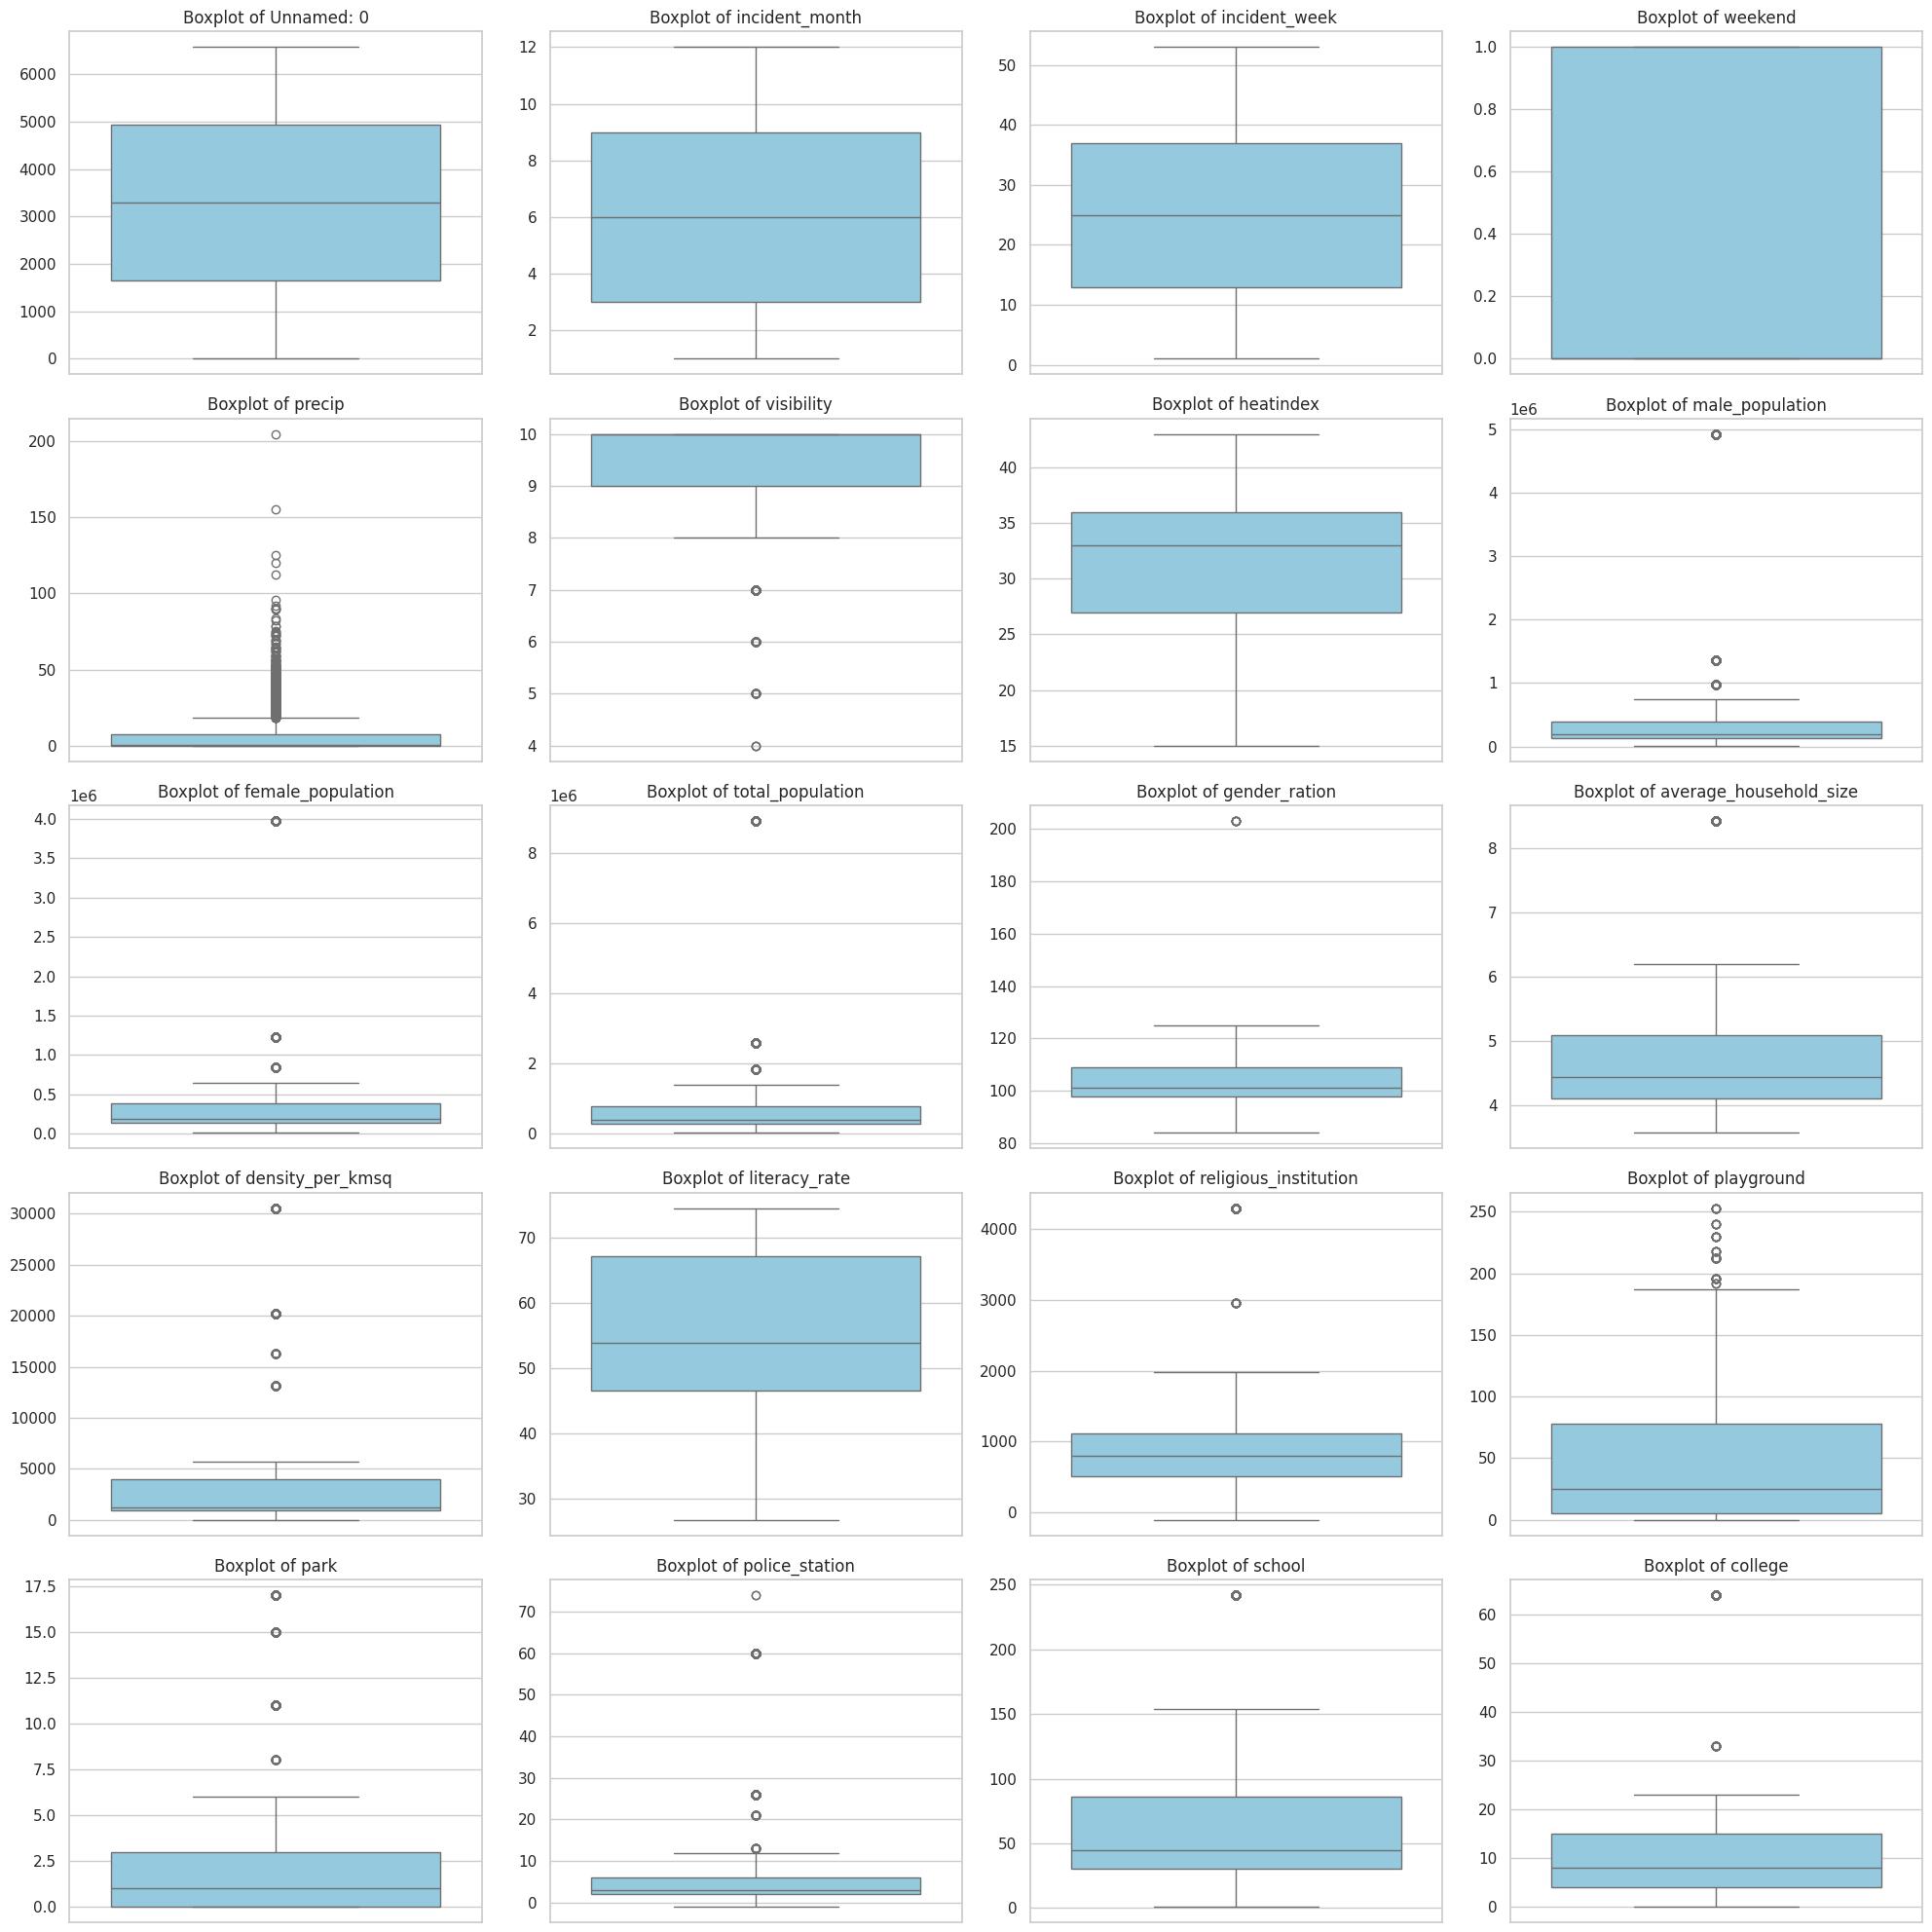

In [121]:
numCols = df.select_dtypes(exclude="object").columns
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(numCols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

In [122]:
outliers_info = {}
audit_results = {}

for col in num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outliers_info[col] = {'count': count, 'lower': lower, 'upper': upper}
audit_results['outliers'] = outliers_info


for col, info in audit_results['outliers'].items():
    print(f"Outlier in {col}: {info['count']} (Range: {info['lower']:.2f} to {info['upper']:.2f})")

Outlier in Unnamed: 0: 0 (Range: -3286.50 to 9859.50)
Outlier in incident_month: 0 (Range: -6.00 to 18.00)
Outlier in incident_week: 0 (Range: -23.00 to 73.00)
Outlier in weekend: 0 (Range: -1.50 to 2.50)
Outlier in precip: 622 (Range: -11.10 to 18.50)
Outlier in visibility: 319 (Range: 7.50 to 11.50)
Outlier in heatindex: 0 (Range: 13.50 to 49.50)
Outlier in male_population: 1250 (Range: -257735.50 to 781372.50)
Outlier in female_population: 1250 (Range: -236745.88 to 751899.12)
Outlier in total_population: 1250 (Range: -500409.50 to 1541418.50)
Outlier in gender_ration: 7 (Range: 81.50 to 125.50)
Outlier in average_household_size: 872 (Range: 2.63 to 6.58)
Outlier in density_per_kmsq: 1274 (Range: -3655.50 to 8556.50)
Outlier in literacy_rate: 0 (Range: 15.70 to 98.10)
Outlier in religious_institution: 883 (Range: -407.75 to 2038.25)
Outlier in playground: 87 (Range: -104.50 to 187.50)
Outlier in park: 1288 (Range: -4.50 to 7.50)
Outlier in police_station: 1225 (Range: -4.00 to 12.00

I decided to keep the outliers for population and density because they represent the real demographic gap in Bangladesh. Dhaka is a mega-city with over 8 million people, which is naturally an outlier compared to other districts. Removing them would make the clustering analysis biased and inaccurate for urban planning.

Beside that, there are high volume of outliers in demographic and infrastructure features. Instead of removing them, which would result in losing critical data about major cities. I used RobustScaler. This method scales the data using the median and quartiles

## **Data Cleaning**

In [123]:
# drop unused column
df = df.drop(columns=['Unnamed: 0'])

In [124]:
# replace placeholders with NaN
df['religious_institution'] = df['religious_institution'].replace(-99.0, np.nan)
df['police_station'] = df['police_station'].replace(-1.0, np.nan)

In [125]:
# impute missing values
# categorical
df['part_of_the_day'] = df['part_of_the_day'].fillna(df['part_of_the_day'].mode()[0])
df['season'] = df['season'].fillna(df['season'].mode()[0])

In [126]:
# numerical
df['precip'] = df['precip'].fillna(df['precip'].median())
df['literacy_rate'] = df['literacy_rate'].fillna(df['literacy_rate'].mean())
df['religious_institution'] = df['religious_institution'].fillna(df['religious_institution'].median())
df['police_station'] = df['police_station'].fillna(df['police_station'].median())

In [127]:
print(df.isnull().sum())

incident_month            0
incident_week             0
incident_weekday          0
weekend                   0
part_of_the_day           0
incident_district         0
incident_division         0
precip                    0
visibility                0
heatindex                 0
season                    0
male_population           0
female_population         0
total_population          0
gender_ration             0
average_household_size    0
density_per_kmsq          0
literacy_rate             0
religious_institution     0
playground                0
park                      0
police_station            0
school                    0
college                   0
crime                     0
dtype: int64


In [128]:
# handle outlier
cols_to_cap = ['precip', 'total_population', 'density_per_kmsq', 'police_station', 'school', 'college']

for col in cols_to_cap:
    lower_limit = df[col].quantile(0.01)
    upper_limit = df[col].quantile(0.99)
    df[col] = df[col].clip(lower_limit, upper_limit)

In [129]:
facilities = ['playground', 'park', 'school', 'college', 'religious_institution', 'police_station']
for col in facilities:
    neg_count = (df[col] < 0).sum()

In [130]:
num = df.select_dtypes(include=[np.number]).columns.tolist()

In [131]:
outliers_info = {}
audit_results = {}

for col in num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outliers_info[col] = {'count': count, 'lower': lower, 'upper': upper}
audit_results['outliers'] = outliers_info


for col, info in audit_results['outliers'].items():
    print(f"Outlier in {col}: {info['count']} (Range: {info['lower']:.2f} to {info['upper']:.2f})")

Outlier in incident_month: 0 (Range: -6.00 to 18.00)
Outlier in incident_week: 0 (Range: -23.00 to 73.00)
Outlier in weekend: 0 (Range: -1.50 to 2.50)
Outlier in precip: 799 (Range: -9.26 to 15.44)
Outlier in visibility: 319 (Range: 7.50 to 11.50)
Outlier in heatindex: 0 (Range: 13.50 to 49.50)
Outlier in male_population: 1250 (Range: -257735.50 to 781372.50)
Outlier in female_population: 1250 (Range: -236745.88 to 751899.12)
Outlier in total_population: 1250 (Range: -500409.50 to 1541418.50)
Outlier in gender_ration: 7 (Range: 81.50 to 125.50)
Outlier in average_household_size: 872 (Range: 2.63 to 6.58)
Outlier in density_per_kmsq: 1274 (Range: -3655.50 to 8556.50)
Outlier in literacy_rate: 0 (Range: 20.15 to 92.55)
Outlier in religious_institution: 883 (Range: -396.50 to 2031.50)
Outlier in playground: 87 (Range: -104.50 to 187.50)
Outlier in park: 1288 (Range: -4.50 to 7.50)
Outlier in police_station: 1225 (Range: -4.00 to 12.00)
Outlier in school: 872 (Range: -54.00 to 170.00)
Outl

In [132]:
daysReference = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']

In [133]:
def fixWeekday(wrong_day):
    if pd.isna(wrong_day):
        return "Unknown"
    wrong_day = str(wrong_day).lower().strip()
    match = difflib.get_close_matches(wrong_day, daysReference, n=1, cutoff=0.3)
    if match:
        return match[0].capitalize()
    else:
        return "Unknown"

In [134]:
df['incident_weekday'] = df['incident_weekday'].apply(fixWeekday)
print(df['incident_weekday'].unique())

['Wednesday' 'Tuesday' 'Friday' 'Thursday' 'Sunday' 'Saturday' 'Monday']


In [135]:
df["incident_weekday"].value_counts()

,count
incident_weekday,
Tuesday,1010
Monday,984
Wednesday,976
Thursday,937
Saturday,917
Friday,883
Sunday,867


In [136]:
logCols = ['total_population', 'density_per_kmsq', 'religious_institution']
for col in logCols:
    df[col] = np.log1p(df[col])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [137]:
# drop redundant column (total population is enough)
df = df.drop(columns=['male_population', 'female_population'])

## **EDA**

/tmp/ipython-input-571295567.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='crime', palette='viridis', order=df['crime'].value_counts().index)


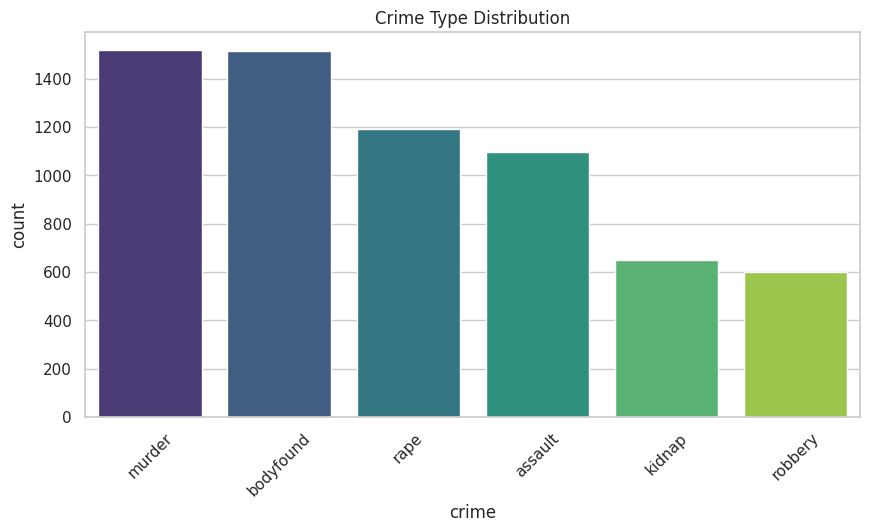

In [138]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='crime', palette='viridis', order=df['crime'].value_counts().index)
plt.title('Crime Type Distribution')
plt.xticks(rotation=45)
plt.show()

The chart shows that Murder and Bodyfound are the dominant crime types in this dataset. This suggests that the records are heavily focused on high-severity violent incidents, while crimes like Robbery and Kidnap occur much less frequently

/tmp/ipython-input-4073490336.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='incident_division', palette='magma')


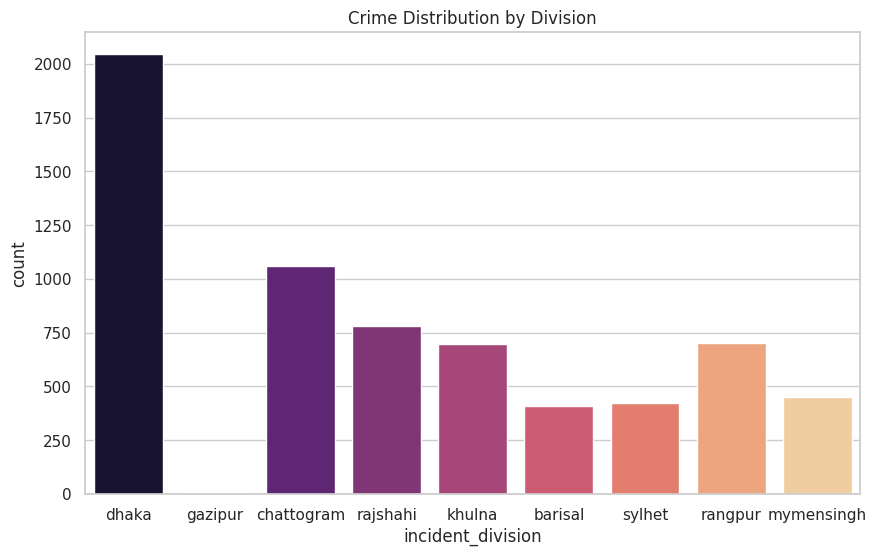

In [139]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='incident_division', palette='magma')
plt.title('Crime Distribution by Division')
plt.show()

Looking at the division chart, Dhaka is clearly the hotspot for crime, having significantly more incidents than any other area. This confirms that our clustering should account for Dhaka as a unique high-density group, while Gazipur remains the division with the fewest reported cases

In [140]:
corrMatrix = df.select_dtypes(include=['number']).corr()

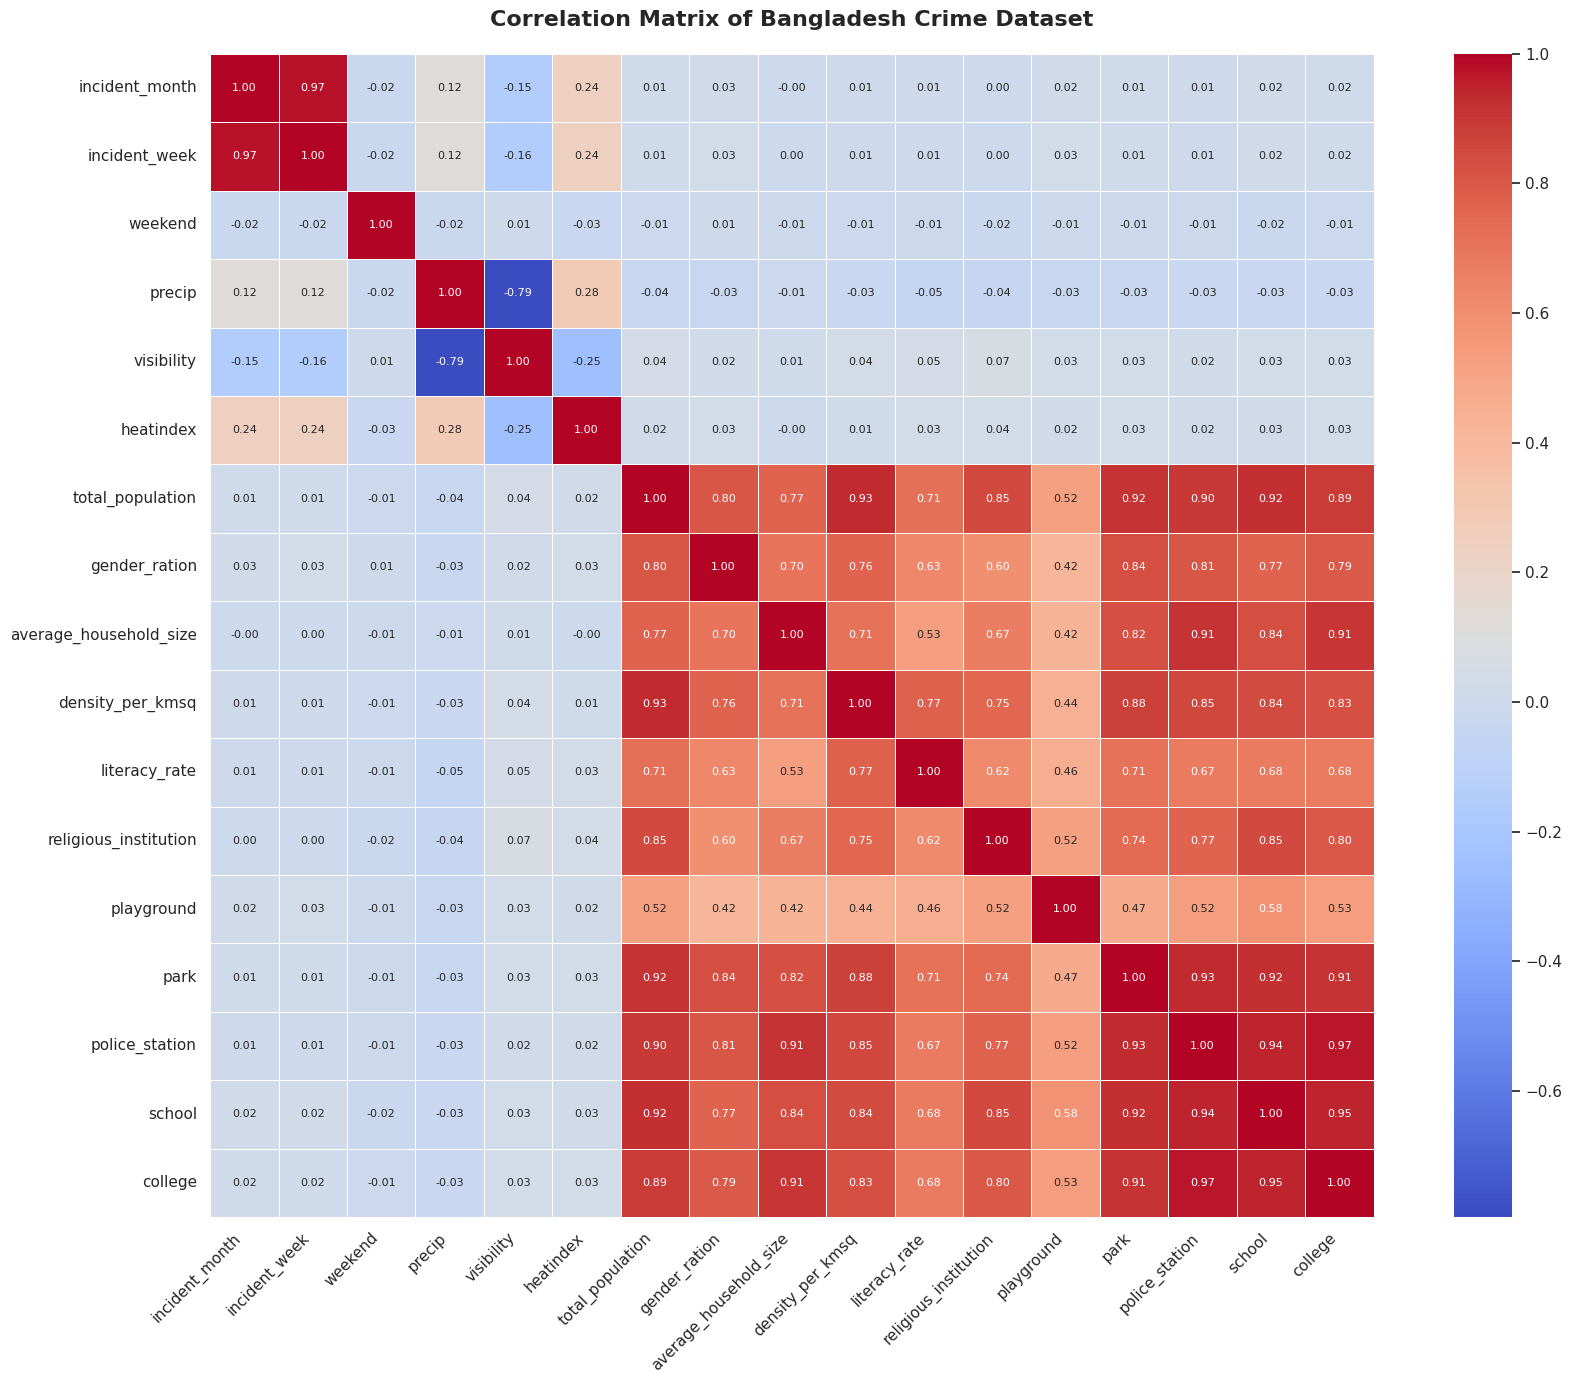

In [141]:
plt.figure(figsize=(18, 14))
sns.heatmap(corrMatrix, annot=True, fmt='.2f', cmap='coolwarm',
            annot_kws={"size": 8}, linewidths=0.5, square=True)
plt.title('Correlation Matrix of Bangladesh Crime Dataset', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

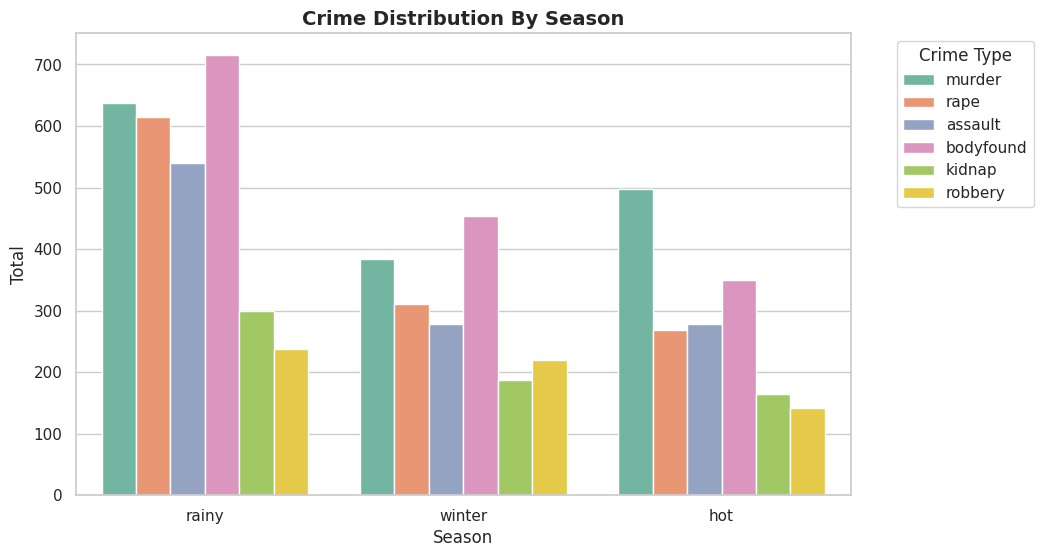

In [142]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='season', hue='crime', palette='Set2')
plt.title('Crime Distribution By Season', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Total')
plt.legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The bar chart reveals that the Rainy season is the most critical period, recording the highest number of total crime incidents compared to other seasons, with a particularly high frequency of Bodyfound and Rape cases. While the total number of reports decreases during the Hot and Winter seasons, serious crimes like Murder still show a high occurrence rate, especially in the hot months. This seasonal pattern suggests that environmental factors during the monsoon may either lead to an increase in certain criminal activities or impact the discovery and reporting of violent incidents across the country.

/tmp/ipython-input-3956152710.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  crimeByWeekday = sns.countplot(data=df, x='incident_weekday', order=dayOrder, palette='plasma')


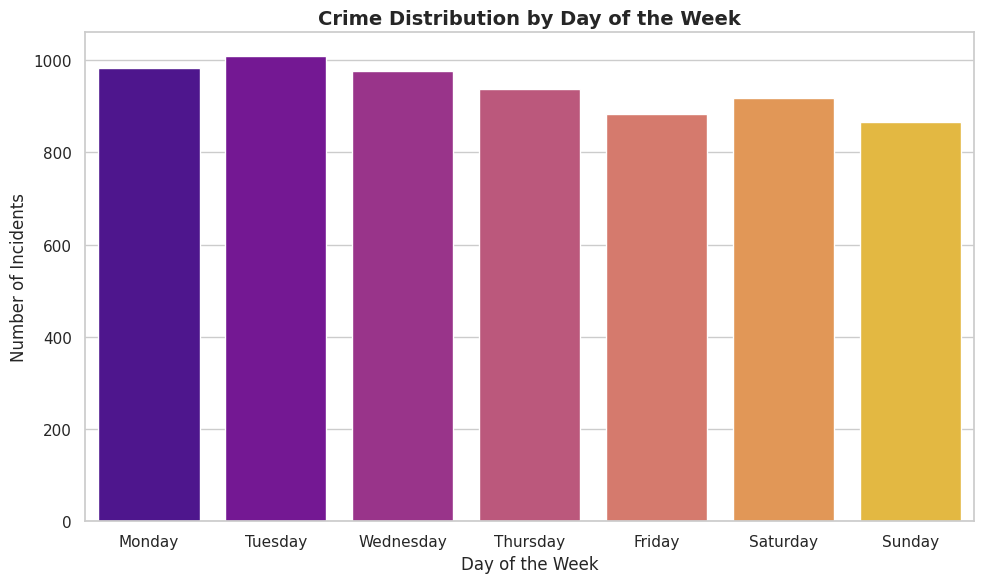

In [143]:
dayOrder = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))
crimeByWeekday = sns.countplot(data=df, x='incident_weekday', order=dayOrder, palette='plasma')
plt.title('Crime Distribution by Day of the Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Incidents')
plt.tight_layout()
plt.show()

The distribution across the week is relatively even, but there is a slight increase in reports during the middle of the week (Tuesday and Wednesday). Interestingly, Friday and Saturday do not show a massive spike, suggesting that crime in this dataset follows a daily work-life routine rather than weekend surges.

/tmp/ipython-input-1796465879.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  literacyBoxplot = sns.boxplot(data=df, x='crime', y='literacy_rate', palette='Set3')


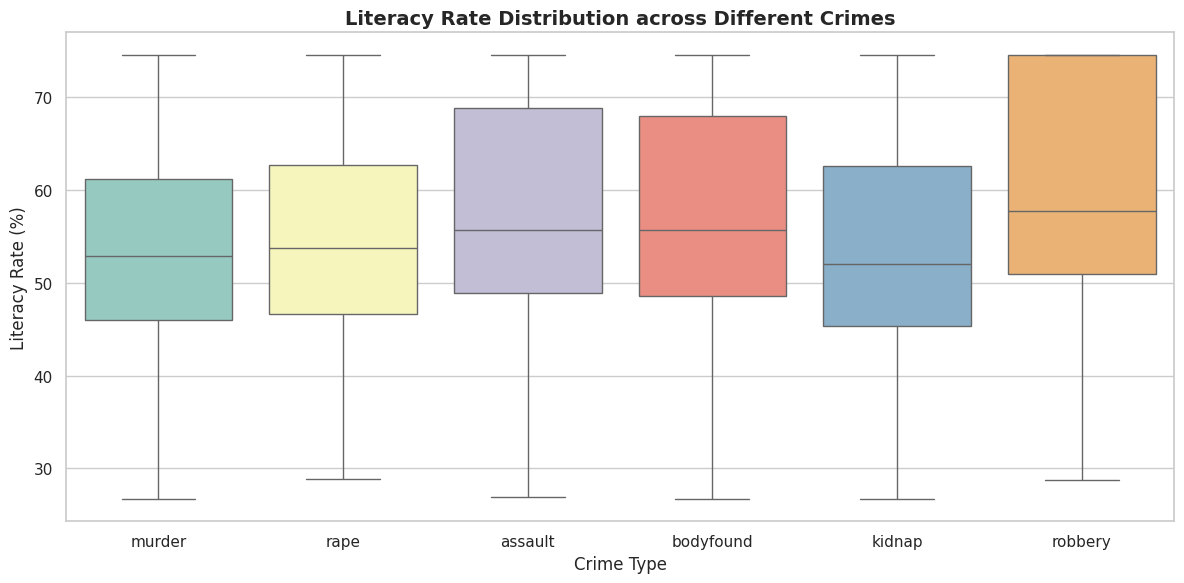

In [144]:
plt.figure(figsize=(12, 6))
literacyBoxplot = sns.boxplot(data=df, x='crime', y='literacy_rate', palette='Set3')
plt.title('Literacy Rate Distribution across Different Crimes', fontsize=14, fontweight='bold')
plt.xlabel('Crime Type')
plt.ylabel('Literacy Rate (%)')
plt.tight_layout()
plt.show()

The literacy rate across all crime types is quite similar, hovering between 50% and 70%. However, crimes like Robbery and Kidnap show a slightly wider range of literacy rates, indicating these crimes happen in both highly educated and less educated districts, whereas Murder reports are more concentrated in districts with average literacy levels.

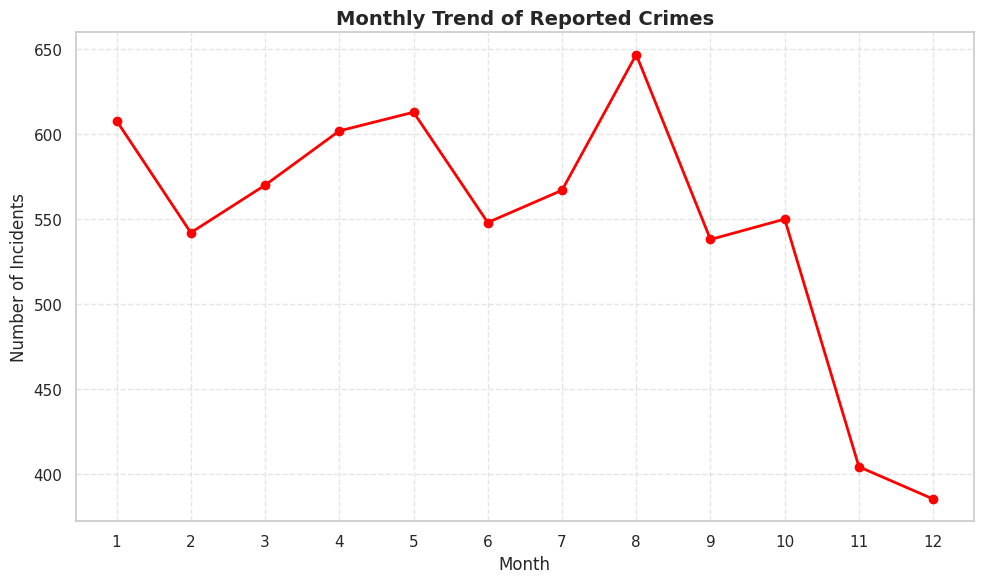

In [145]:
plt.figure(figsize=(10, 6))
monthlyCounts = df['incident_month'].value_counts().sort_index()
plt.plot(monthlyCounts.index, monthlyCounts.values, marker='o', linestyle='-', color='red', linewidth=2)

plt.title('Monthly Trend of Reported Crimes', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The monthly trend shows significant fluctuations. Crime reports peak during the middle of the year (May to July), which coincides with the Rainy season. There is a noticeable drop towards the end of the year (November and December), suggesting that weather or seasonal activities might influence either the crime rate or the reporting process.

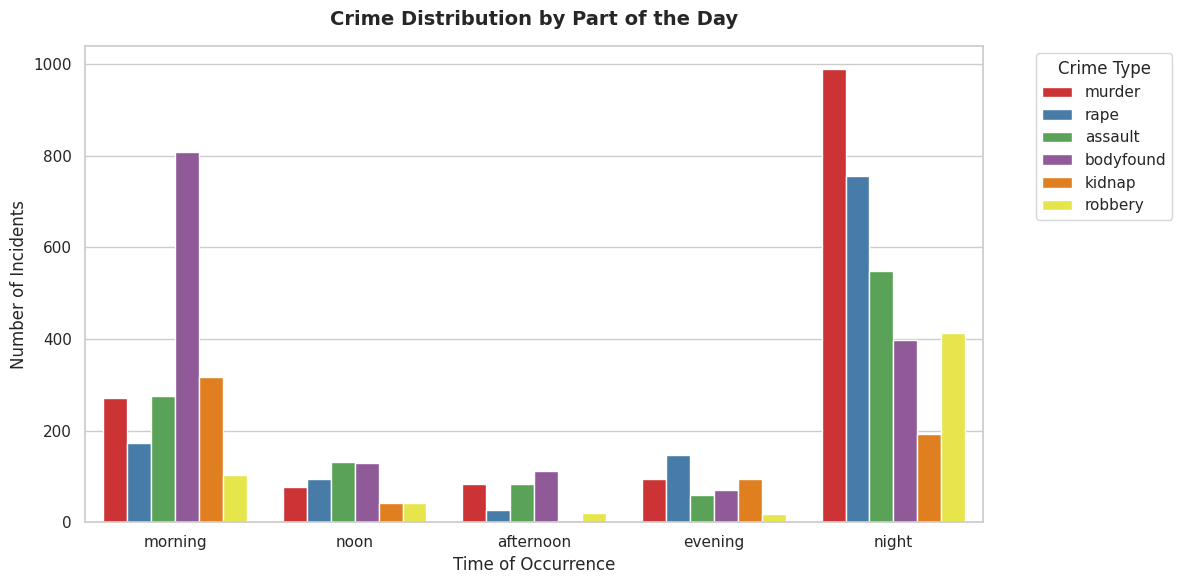

In [146]:
plt.figure(figsize=(12, 6))
dayOrder = ['morning', 'noon', 'afternoon', 'evening', 'night']
partOfDayPlot = sns.countplot(data=df, x='part_of_the_day', hue='crime', palette='Set1', order=dayOrder)
plt.title('Crime Distribution by Part of the Day', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time of Occurrence', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The chart indicates that Night and Morning are the most active periods for reported crimes. High-severity incidents like Murder and Rape are most frequently recorded during the night, whereas Bodyfound cases are predominantly discovered during the morning hours.

/tmp/ipython-input-230901226.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  weekendPlot = sns.countplot(data=df, x='dayType', palette='cool')


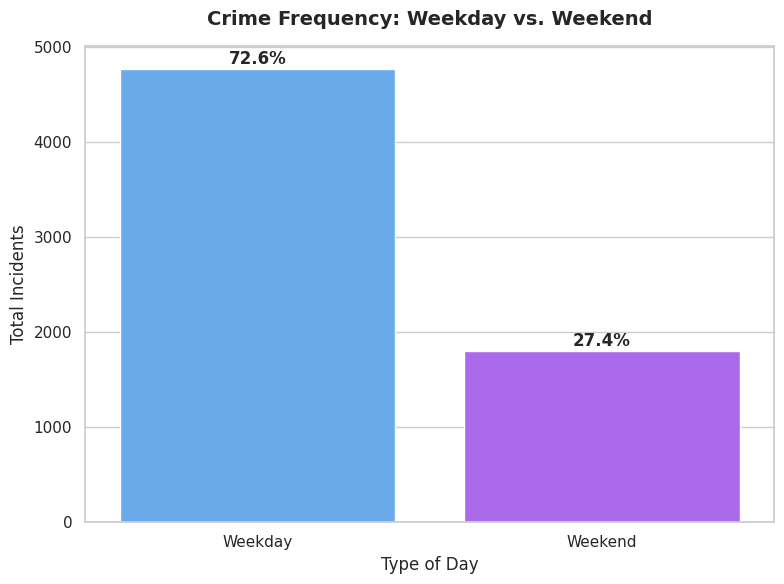

In [147]:
plt.figure(figsize=(8, 6))
df['dayType'] = df['weekend'].map({1: 'Weekend', 0: 'Weekday'})
weekendPlot = sns.countplot(data=df, x='dayType', palette='cool')
plt.title('Crime Frequency: Weekday vs. Weekend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Type of Day', fontsize=12)
plt.ylabel('Total Incidents', fontsize=12)

totalIncidents = len(df)
for p in weekendPlot.patches:
    percentageValue = f'{100 * p.get_height() / totalIncidents:.1f}%'
    xAxis = p.get_x() + p.get_width() / 2
    yAxis = p.get_height() + 50
    weekendPlot.annotate(percentageValue, (xAxis, yAxis), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

A significant majority of crimes (72.6%) occur during Weekdays, while only 27.4% happen over the Weekend. This suggests that criminal activity in these districts is closely tied to daily social and economic routines rather than peaking during leisure time.

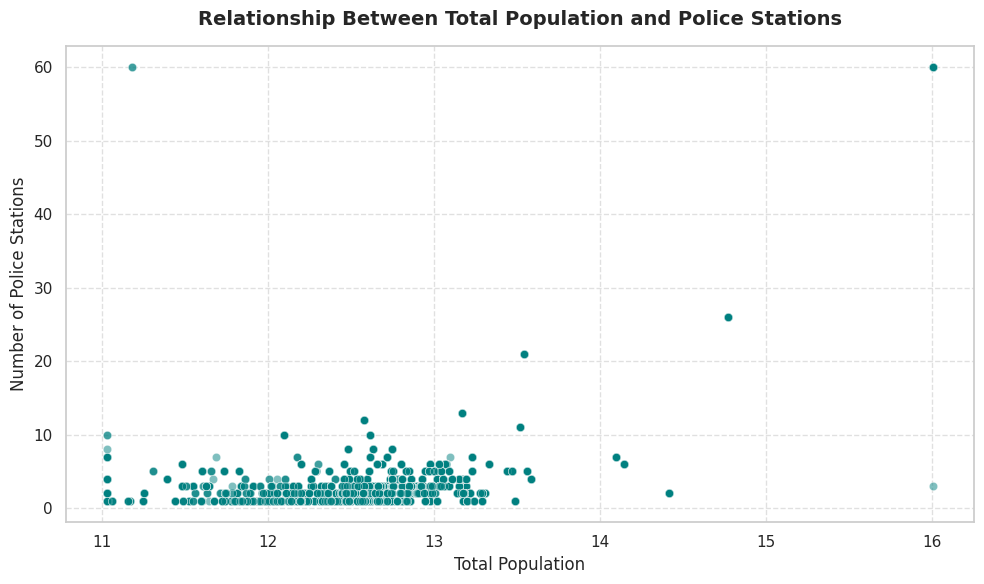

In [148]:
plt.figure(figsize=(10, 6))
popPolicePlot = sns.scatterplot(data=df, x='total_population', y='police_station', alpha=0.5, color='teal')
plt.title('Relationship Between Total Population and Police Stations', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Population', fontsize=12)
plt.ylabel('Number of Police Stations', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The scatter plot demonstrates a strong positive linear trend, showing that police stations are generally distributed according to population size. However, the extreme data points at the top-right corner once again highlight the massive infrastructure gap between the Dhaka metropolitan area and the rest of the country.

## **Encode**

In [149]:
labelEnc = LabelEncoder()

In [150]:
for col in cat:
    df[col] = labelEnc.fit_transform(df[col].astype(str))

if 'incident_district' in df.columns:
    dfCrime = df.drop(columns=['incident_district'])

In [151]:
df.head()

,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,heatindex,...,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime,dayType
0,7,29,6,0,2,13,2,6.1,10,32,...,10.327185,74.6,8.364042,99,17,60.0,242,64,3,Weekday
1,1,2,6,0,3,13,2,0.0,10,22,...,10.327185,74.6,8.364042,99,17,60.0,242,64,3,Weekday
2,1,4,5,0,3,13,2,0.0,10,25,...,10.327185,74.6,8.364042,99,17,60.0,242,64,3,Weekday
3,3,9,0,1,3,13,2,0.0,10,30,...,10.327185,74.6,8.364042,99,17,60.0,242,64,3,Weekend
4,8,34,4,0,3,13,2,21.9,9,38,...,10.327185,74.6,8.364042,99,17,60.0,242,64,3,Weekday


## **K-Means**

In [152]:
num = df.select_dtypes(exclude = "object").columns
num

Index(['incident_month', 'incident_week', 'incident_weekday', 'weekend',
       'part_of_the_day', 'incident_district', 'incident_division', 'precip',
       'visibility', 'heatindex', 'season', 'total_population',
       'gender_ration', 'average_household_size', 'density_per_kmsq',
       'literacy_rate', 'religious_institution', 'playground', 'park',
       'police_station', 'school', 'college', 'crime'],
      dtype='object')

In [153]:
df.isnull().sum()

,0
incident_month,0
incident_week,0
incident_weekday,0
weekend,0
part_of_the_day,0
incident_district,0
incident_division,0
precip,0
visibility,0
heatindex,0


In [154]:
finalImputer = SimpleImputer(strategy='median')
df[num] = finalImputer.fit_transform(df[num])

In [155]:
df.isnull().sum()

,0
incident_month,0
incident_week,0
incident_weekday,0
weekend,0
part_of_the_day,0
incident_district,0
incident_division,0
precip,0
visibility,0
heatindex,0


In [156]:
# this is crucial because features like population have a much larger scale than others
# robustScaler is chosen because it is resistant to outliers
scalerObj = RobustScaler()
scaledData = scalerObj.fit_transform(df[num])

In [157]:
inertiaList = []
silhouetteList = []
kRange = range(2, 11)

In [158]:
for k in kRange:
    tempKMeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    tempKMeans.fit(scaledData)

    inertiaList.append(tempKMeans.inertia_)
    silhouetteList.append(silhouette_score(scaledData, tempKMeans.labels_))

plt.figure(figsize=(15, 5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

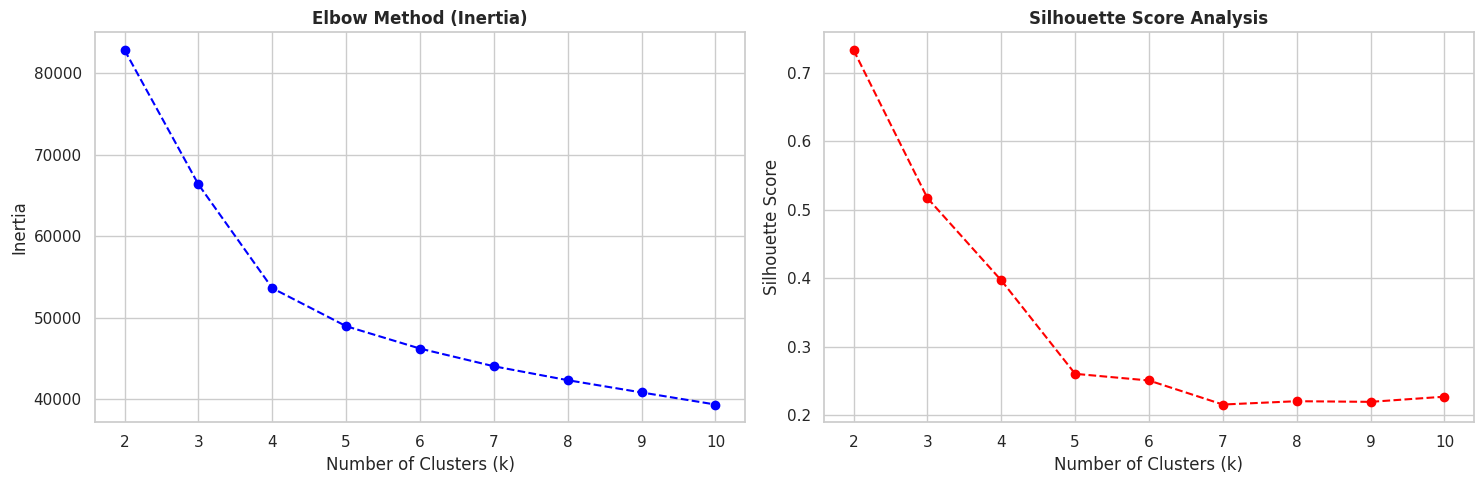

In [159]:
plt.figure(figsize=(15, 5))
# plot elbow method
plt.subplot(1, 2, 1)
plt.plot(kRange, inertiaList, marker='o', color='blue', linestyle='--')
plt.title('Elbow Method (Inertia)', fontsize=12, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

# plot silhouette score
plt.subplot(1, 2, 2)
plt.plot(kRange, silhouetteList, marker='o', color='red', linestyle='--')
plt.title('Silhouette Score Analysis', fontsize=12, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [160]:
optimalK = 3
finalKMeans = KMeans(n_clusters=optimalK, random_state=42, n_init=10)

In [161]:
df['cluster'] = finalKMeans.fit_predict(scaledData)

In [162]:
pcaModel = PCA(n_components=2)
pcaData = pcaModel.fit_transform(scaledData)
df['pcaOne'] = pcaData[:, 0]
df['pcaTwo'] = pcaData[:, 1]

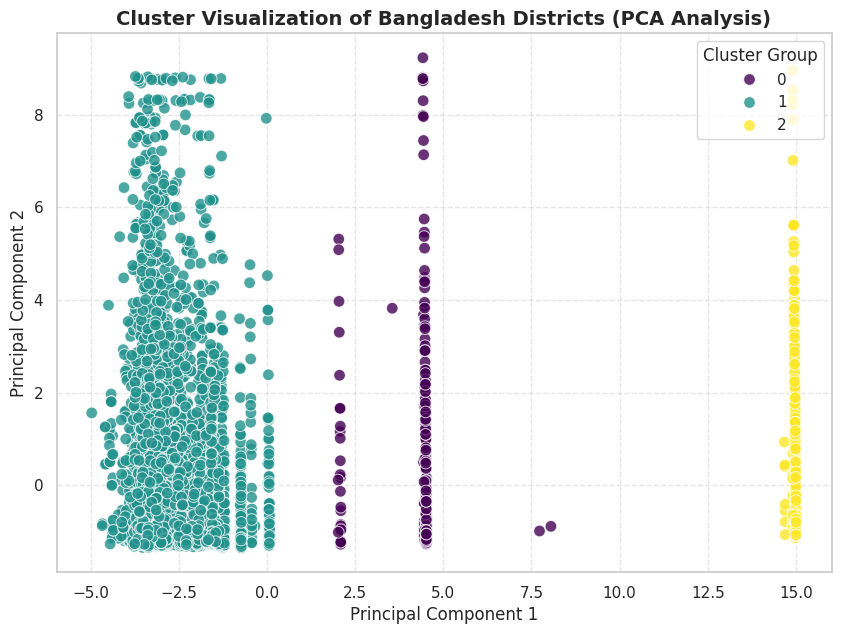

In [163]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='pcaOne', y='pcaTwo', hue='cluster', palette='viridis', s=70, alpha=0.8)
plt.title('Cluster Visualization of Bangladesh Districts (PCA Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster Group', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The PCA scatter plot visualizes how the districts are grouped based on their demographic and infrastructure patterns. Principal Component 1 (PC1) on the x-axis represents the Urbanization Scale points further to the right are areas with extreme population density and massive infrastructure (like Dhaka).

By using $K=3$, the model effectively classifies the regions into three distinct profiles:
* Cluster 0 (The Hubs):These are the outliers on the far right, representing mega-cities with the highest concentration of people and police stations
* Cluster 1 (The Developing Districts): Positioned in the middle, these are districts with moderate growth and a balanced number of facilities.
* Cluster 2 (The Rural Areas): Clustered on the left, these represent less populated regions with basic infrastructure.

This separation confirms that the level of development is the primary factor that distinguishes districts in Bangladesh.

## **Profiling**

In [164]:
clusterSummary = df.groupby('cluster').agg({
    'total_population': 'mean',
    'density_per_kmsq': 'mean',
    'police_station': 'mean',
    'literacy_rate': 'mean',
    'school': 'mean'
}).reset_index()

In [165]:
print("Final Cluster Profiles")
print(clusterSummary)

Final Cluster Profiles
   cluster  total_population  density_per_kmsq  police_station  literacy_rate  \
0        0         14.615301          9.863773       25.588415      68.280042   
1        1         12.741075          7.096850        3.102326      52.055167   
2        2         16.002240         10.327185       60.000000      73.777293   

       school  
0  127.939024  
1   44.995163  
2  242.000000  


/tmp/ipython-input-3650255530.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster', y=col, palette='viridis')
/tmp/ipython-input-3650255530.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster', y=col, palette='viridis')
/tmp/ipython-input-3650255530.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster', y=col, palette='viridis')
/tmp/ipython-input-3650255530.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` v

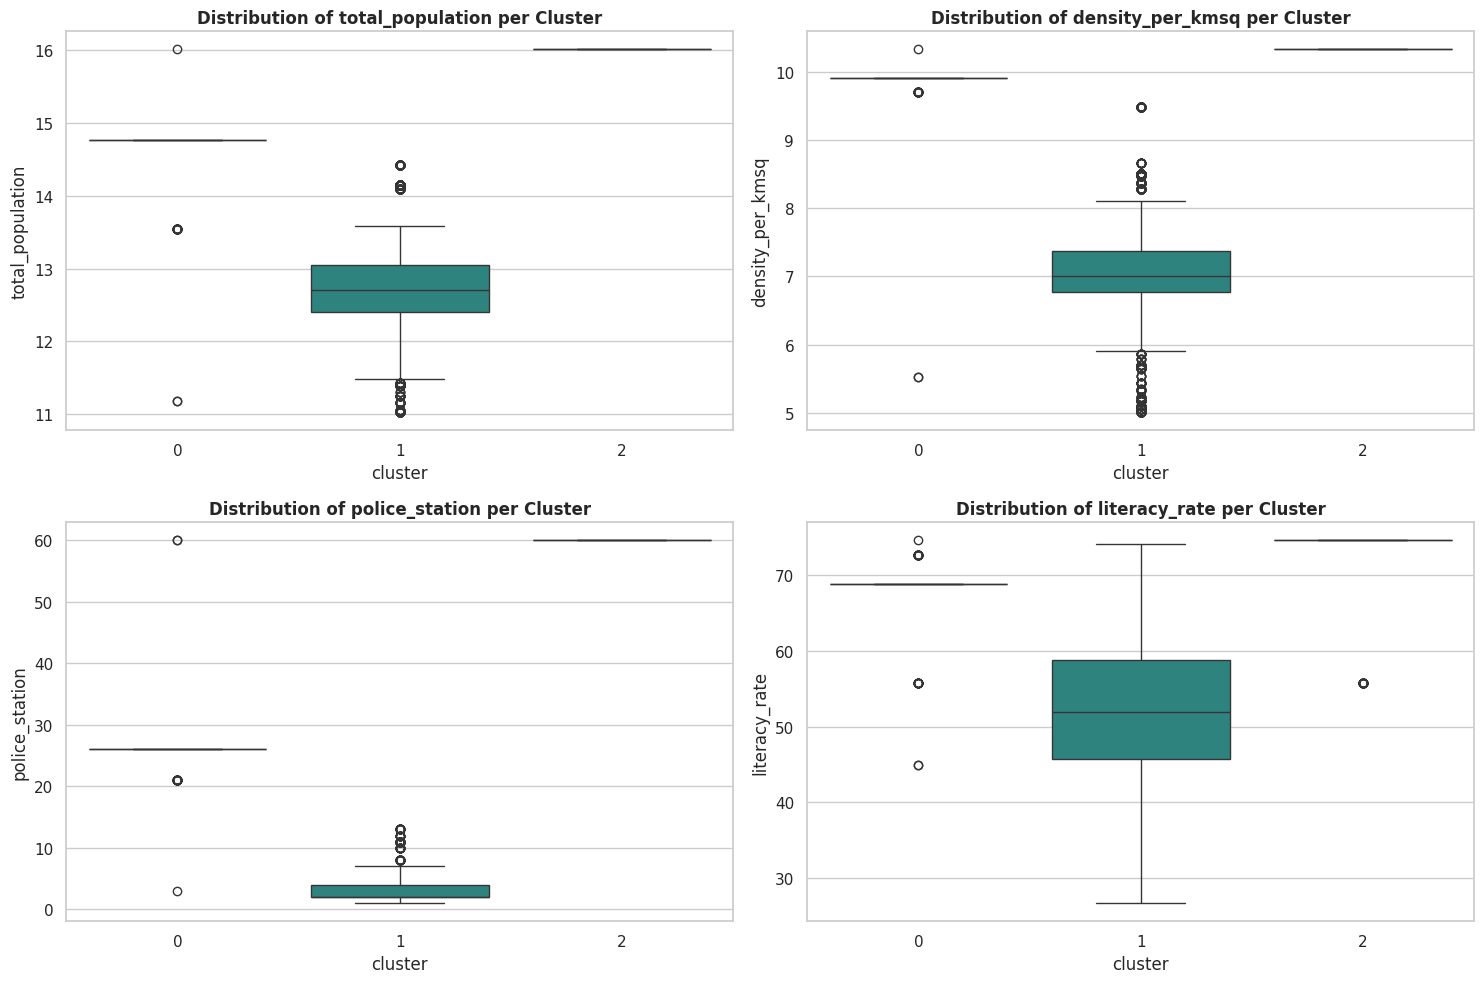

In [166]:
plt.figure(figsize=(15, 10))
featuresToCompare = ['total_population', 'density_per_kmsq', 'police_station', 'literacy_rate']
for i, col in enumerate(featuresToCompare):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=df, x='cluster', y=col, palette='viridis')
    plt.title(f'Distribution of {col} per Cluster', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [167]:
clusterDivisionMap = pd.crosstab(df['incident_division'], df['cluster'])

print("Distribution of Clusters across Divisions")
print(clusterDivisionMap)

Distribution of Clusters across Divisions
cluster              0     1    2
incident_division                
0.0                  0   408    0
1.0                291   770    0
2.0                  1  1174  871
3.0                  0     4    0
4.0                 36   661    0
5.0                  0   449    0
6.0                  0   782    0
7.0                  0   703    0
8.0                  0   424    0


In [168]:
print("Number of Districts in Each Cluster")
print(df['cluster'].value_counts())

Number of Districts in Each Cluster
cluster
1    5375
2     871
0     328
Name: count, dtype: int64


In [169]:
def assignLabel(clusterId):
    if clusterId == 0: return "Urban Pressure Cooker (High Risk)"
    elif clusterId == 1: return "Developing Backbone (Medium Risk)"
    else: return "Quiet Frontier (Low Risk)"

df['clusterName'] = df['cluster'].apply(assignLabel)

In [170]:
print("Sample Cluster Assignments")
print(df[['incident_division', 'clusterName']].head(10))

Sample Cluster Assignments
   incident_division                        clusterName
0                2.0          Quiet Frontier (Low Risk)
1                2.0          Quiet Frontier (Low Risk)
2                2.0          Quiet Frontier (Low Risk)
3                2.0          Quiet Frontier (Low Risk)
4                2.0          Quiet Frontier (Low Risk)
5                2.0          Quiet Frontier (Low Risk)
6                2.0  Developing Backbone (Medium Risk)
7                2.0  Developing Backbone (Medium Risk)
8                2.0  Developing Backbone (Medium Risk)
9                2.0  Developing Backbone (Medium Risk)


While the EDA highlights immediate patterns like Dhaka being a crime hotspot and the Rainy season being the most dangerous, the K-Means Clustering provides a strategic roadmap. By segmenting the country into three clusters : Urban Hubs, Developing Districts, and Rural Areas

We move from just observing data to making decisions. We found that infrastructure development directly correlates with crime reporting volume.

Therefore, our recommendation is that the government should prioritize high-density surveillance in Cluster 0 while focusing on long-term educational infrastructure in Cluster 2 to address the root causes of regional disparity.